## Stage 4D — Attention Decoder Ablation (Transfer Learning)
Goal: replace simple image-feature concat with cross-attention over CNN spatial tokens.
This is an architecture ablation against Stage 4 baseline.


In [2]:
# Cell 1 — setup + GPU check
from pathlib import Path
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/dannyyy/Downloads/accessops_coco_ai"),
]

def find_project_root():
    for c in CANDIDATE_ROOTS:
        if (c / "artifacts" / "captions_clean_with_splits.csv").exists():
            return c
    raise FileNotFoundError("Could not find project root.")

PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"
PREPROC_CFG = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config.json"
TOKENIZER_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage4d_attention"
MODEL_DIR = PROJECT_ROOT / "models" / "stage4d_attention"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ART_DIR:", ART_DIR)
print("MODEL_DIR:", MODEL_DIR)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected."


PROJECT_ROOT: /Users/dannyyy/Downloads/accessops_coco_ai
ART_DIR: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage4d_attention
MODEL_DIR: /Users/dannyyy/Downloads/accessops_coco_ai/models/stage4d_attention
TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 2 — tokenizer + sequence config
cfg = json.loads(PREPROC_CFG.read_text(encoding="utf-8"))
MAX_LEN = int(cfg["sequence"]["max_length"])
VOCAB_SIZE = int(cfg["vocab"]["selected_vocab_size"])
SEQ_LEN = MAX_LEN - 1

tokenizer = tokenizer_from_json(TOKENIZER_PATH.read_text(encoding="utf-8"))
start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")
assert start_id is not None and end_id is not None, "Missing <start>/<end> ids"

print("MAX_LEN:", MAX_LEN, "SEQ_LEN:", SEQ_LEN, "VOCAB_SIZE:", VOCAB_SIZE)
print("start_id:", start_id, "end_id:", end_id)


MAX_LEN: 30 SEQ_LEN: 29 VOCAB_SIZE: 30000
start_id: 3 end_id: 4


In [4]:
# Cell 3 (REPLACE) — load data + robust local image path resolution + references
df = pd.read_csv(CSV_PATH)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str).str.strip().str.lower()
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

if "image_name" not in df.columns and "image_path" in df.columns:
    df["image_name"] = df["image_path"].astype(str).map(lambda p: Path(p).name)
df["image_name"] = df["image_name"].astype(str).str.strip()

print("Before path resolution:")
print(df["split"].value_counts())

# Your local COCO dirs (including artifacts/data/coco)
COCO_DIRS = [
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "val2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "test2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "raw" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "raw" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "test2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "val2017",
]
COCO_DIRS = [p for p in COCO_DIRS if p.exists()]

print("\nFound COCO dirs:")
for p in COCO_DIRS:
    print(" -", p)

def resolve_image_path(row):
    n = str(row.get("image_name", "")).strip()
    s = str(row.get("split", "")).strip().lower()
    if not n:
        return None

    # try split-aware first
    if s == "train":
        preferred = [d for d in COCO_DIRS if "train2017" in str(d)]
    else:
        # val/test both come from val2017 split in your project
        preferred = [d for d in COCO_DIRS if "val2017" in str(d)] + [d for d in COCO_DIRS if "test2017" in str(d)]

    for d in preferred:
        p = d / n
        if p.exists():
            return str(p.resolve())

    # fallback: search all
    for d in COCO_DIRS:
        p = d / n
        if p.exists():
            return str(p.resolve())

    return None

df["image_path_resolved"] = df.apply(resolve_image_path, axis=1)

missing = df["image_path_resolved"].isna().sum()
print(f"\nMissing resolved paths: {missing} / {len(df)}")

df = df[df["image_path_resolved"].notna()].reset_index(drop=True)

print("\nAfter path resolution:")
print(df["split"].value_counts())
print("\nUnique images by split:")
print(df.groupby("split")["image_name"].nunique())

assert (df["split"] == "train").sum() > 0, "Train split is empty after path resolution."
assert (df["split"] == "val").sum() > 0, "Val split is empty after path resolution."
assert (df["split"] == "test").sum() > 0, "Test split is empty after path resolution."

references_by_image = (
    df[df["split"] == "test"]
    .groupby("image_name")["comment_clean"]
    .apply(list)
    .to_dict()
)
image_path_by_name = (
    df.groupby("image_name", as_index=False)["image_path_resolved"]
    .first()
    .set_index("image_name")["image_path_resolved"]
    .to_dict()
)

print("\nCell 3 fixed ✅")


Before path resolution:
split
train    591753
val       12508
test      12506
Name: count, dtype: int64

Found COCO dirs:
 - /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/data/coco/train2017
 - /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/data/coco/val2017

Missing resolved paths: 0 / 616767

After path resolution:
split
train    591753
val       12508
test      12506
Name: count, dtype: int64

Unique images by split:
split
test       2500
train    118287
val        2500
Name: image_name, dtype: int64

Cell 3 fixed ✅


In [5]:
# Cell 4 — sequences + split arrays
def wrap_caption(c):
    return f"<start> {c} <end>"

df["caption_wrapped"] = df["comment_clean"].map(wrap_caption)
seq = tokenizer.texts_to_sequences(df["caption_wrapped"].tolist())
seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post").astype(np.int32)
df["seq"] = list(seq)

def make_split(split_name):
    part = df[df["split"] == split_name].reset_index(drop=True)
    names = part["image_name"].astype(str).to_numpy()
    paths = part["image_path_resolved"].astype(str).to_numpy()
    seqm = np.stack(part["seq"].to_numpy())
    dec_in = seqm[:, :-1]
    y_out = seqm[:, 1:]
    return names, paths, dec_in, y_out

train_names, train_paths, train_dec_in, train_y = make_split("train")
val_names, val_paths, val_dec_in, val_y = make_split("val")
test_names, test_paths, test_dec_in, test_y = make_split("test")

split_sizes = {
    "train_caption_rows": int(len(train_names)),
    "val_caption_rows": int(len(val_names)),
    "test_caption_rows": int(len(test_names)),
    "train_unique_images": int(pd.Series(train_names).nunique()),
    "val_unique_images": int(pd.Series(val_names).nunique()),
    "test_unique_images": int(pd.Series(test_names).nunique()),
}
(ART_DIR / "selected_split_sizes.json").write_text(json.dumps(split_sizes, indent=2), encoding="utf-8")
print(json.dumps(split_sizes, indent=2))


{
  "train_caption_rows": 591753,
  "val_caption_rows": 12508,
  "test_caption_rows": 12506,
  "train_unique_images": 118287,
  "val_unique_images": 2500,
  "test_unique_images": 2500
}


In [6]:
# Cell 5 — tf.data
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def load_example(path, dec_in, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return {"image_input": img, "text_input": tf.cast(dec_in, tf.int32)}, tf.cast(y, tf.int32)

def augment(inputs, y):
    img = inputs["image_input"]
    txt = inputs["text_input"]
    img = tf.image.random_flip_left_right(img)
    img = tf.clip_by_value(img + tf.random.uniform(tf.shape(img), -0.04, 0.04), -1.0, 1.0)
    return {"image_input": img, "text_input": txt}, y

def make_ds(paths, dec_in, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, dec_in, y))
    ds = ds.map(load_example, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(len(paths), 50000), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_dec_in, train_y, training=True)
val_ds = make_ds(val_paths, val_dec_in, val_y, training=False)
test_ds = make_ds(test_paths, test_dec_in, test_y, training=False)

print("Datasets ready")


Datasets ready


2026-04-11 04:31:54.858791: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-11 04:31:54.858842: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-11 04:31:54.858849: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-11 04:31:54.859044: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-11 04:31:54.859063: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
# Cell 6 — build ATTENTION model (Stage 4D)
tf.keras.backend.clear_session()

base_cnn = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,            # keep spatial map (7x7x1280)
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_cnn.trainable = False

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
feat_map = base_cnn(image_input, training=False)                # [B, 7, 7, 1280]
img_tokens = layers.Reshape((-1, 1280), name="img_tokens")(feat_map)  # [B, 49, 1280]
img_tokens = layers.Dense(512, activation="relu")(img_tokens)
img_tokens = layers.Dropout(0.20)(img_tokens)

text_input = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="text_input")
emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=384, mask_zero=False)(text_input)
dec_seq = layers.LSTM(512, return_sequences=True, dropout=0.30)(emb)

cross_attn = layers.MultiHeadAttention(
    num_heads=4, key_dim=128, dropout=0.10, name="cross_attention"
)(query=dec_seq, key=img_tokens, value=img_tokens)

x = layers.Concatenate(axis=-1)([dec_seq, cross_attn])          # [B, SEQ_LEN, 1024]
x = layers.LayerNormalization()(x)
x = layers.TimeDistributed(layers.Dense(512, activation="relu"))(x)
x = layers.Dropout(0.30)(x)
out = layers.TimeDistributed(
    layers.Dense(VOCAB_SIZE, activation="softmax", dtype="float32")
)(x)

model = models.Model(inputs=[image_input, text_input], outputs=out)

scce = tf.keras.losses.SparseCategoricalCrossentropy(reduction="none")

def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = scce(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    match = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(match * mask) / (tf.reduce_sum(mask) + 1e-8)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False,
)

model.summary()
print("Stage 4D attention model ready ✅")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_tokens          │ (None, 49, 1280)  │          0 │ mobilenetv2_1.00… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 29, 384)   │ 11,520,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 49, 512)   │    655,872 │ img_tokens[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 29, 512)   │  1,837,056 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 512)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ (None, 29, 512)   │  1,050,624 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ lstm[0][0],       │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 29, 1024)  │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ cross_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 29, 1024)  │      2,048 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 29, 512)   │    524,800 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 29, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 29, 30000) │ 15,390,000 │ dropout_2[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,238,384 (126.79 MB)

 Trainable params: 30,980,400 (118.18 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Stage 4D attention model ready ✅


In [ ]:
# Cell 7 — Phase 1 (frozen encoder)
ckpt_frozen = MODEL_DIR / "best_stage4d_attention_frozen.keras"
cb1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt_frozen), monitor="val_loss", save_best_only=True),
    callbacks.TerminateOnNaN(),
]

history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=cb1,
    verbose=1,
)
print("Phase 1 done. Best ckpt:", ckpt_frozen)


Epoch 1/6


2026-04-10 19:11:19.260520: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-10 19:11:30.737023: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 18349 of 50000
2026-04-10 19:11:50.639488: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 48326 of 50000
2026-04-10 19:11:53.326369: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 9621s 518ms/step - loss: 5.0319 - masked_accuracy: 0.3624 - val_loss: 4.8414 - val_masked_accuracy: 0.3859 - learning_rate: 0.0010
Epoch 2/6


2026-04-10 21:51:49.013579: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 19003 of 50000
2026-04-10 21:52:08.291214: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 9047s 487ms/step - loss: 4.4401 - masked_accuracy: 0.3872 - val_loss: 4.4835 - val_masked_accuracy: 0.4016 - learning_rate: 0.0010
Epoch 3/6


2026-04-11 00:22:35.738569: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 18992 of 50000
2026-04-11 00:22:45.749286: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 33692 of 50000
2026-04-11 00:22:57.698927: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


In [8]:
# Check if checkpoint was saved up to epoch 3
from pathlib import Path
import time

for p in sorted(Path(MODEL_DIR).glob("*.keras")):
    print(p.name, "|", time.ctime(p.stat().st_mtime), "|", round(p.stat().st_size/1e6, 2), "MB")


best_stage4d_attention_frozen.keras | Sat Apr 11 00:22:25 2026 | 381.45 MB


In [9]:
# 1) Verify checkpoints
from pathlib import Path
import time

for p in sorted(Path(MODEL_DIR).glob("*.keras")):
    print(p.name, "|", time.ctime(p.stat().st_mtime), "|", round(p.stat().st_size/1e6, 2), "MB")

# 2) Load Phase-1 best frozen checkpoint
ckpt_frozen = MODEL_DIR / "best_stage4d_attention_frozen.keras"
assert ckpt_frozen.exists(), f"Missing: {ckpt_frozen}"
model.load_weights(str(ckpt_frozen), skip_mismatch=False)
print("Loaded:", ckpt_frozen)


best_stage4d_attention_frozen.keras | Sat Apr 11 00:22:25 2026 | 381.45 MB
Loaded: /Users/dannyyy/Downloads/accessops_coco_ai/models/stage4d_attention/best_stage4d_attention_frozen.keras


/Users/dannyyy/miniconda/envs/tf_caption/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
# Phase 2 trainability
base_cnn.trainable = True
for layer in base_cnn.layers[:-40]:
    layer.trainable = False
for layer in base_cnn.layers[-40:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

model.compile(
    optimizer=optimizers.AdamW(learning_rate=5e-5, weight_decay=1e-4),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False
)

ckpt_best = MODEL_DIR / "best_stage4d_attention_finetune.keras"
ckpt_each = MODEL_DIR / "stage4d_attention_finetune_epoch{epoch:02d}.keras"

cb2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
    callbacks.ModelCheckpoint(str(ckpt_best), monitor="val_loss", save_best_only=True),
    callbacks.ModelCheckpoint(str(ckpt_each), monitor="val_loss", save_best_only=False),
    callbacks.TerminateOnNaN(),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    initial_epoch=0,
    callbacks=cb2,
    verbose=1
)


Epoch 1/6


2026-04-11 04:48:04.152729: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-11 04:48:16.968845: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 19000 of 50000
2026-04-11 04:48:35.969726: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 49340 of 50000
2026-04-11 04:48:36.667712: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 9834s 529ms/step - loss: 3.9534 - masked_accuracy: 0.4012 - val_loss: 5.1674 - val_masked_accuracy: 0.3966 - learning_rate: 5.0000e-05
Epoch 2/6


2026-04-11 07:32:06.726584: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17586 of 50000
2026-04-11 07:32:26.731687: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 48753 of 50000
2026-04-11 07:32:28.148483: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - loss: 3.8706 - masked_accuracy: 0.4031
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
18493/18493 ━━━━━━━━━━━━━━━━━━━━ 9582s 515ms/step - loss: 3.8227 - masked_accuracy: 0.4121 - val_loss: 5.3274 - val_masked_accuracy: 0.3997 - learning_rate: 5.0000e-05
Epoch 3/6


...

18493/18493 ━━━━━━━━━━━━━━━━━━━━ 11120s 599ms/step - loss: 3.8793 - masked_accuracy: 0.4113 - val_loss: 5.1063 - val_masked_accuracy: 0.4031 - learning_rate: 2.5000e-05
Epoch 5/6


2026-04-11 16:17:31.533448: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 16607 of 50000
2026-04-11 16:17:41.610375: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 30939 of 50000
2026-04-11 16:17:55.973310: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 12511s 674ms/step - loss: 3.8703 - masked_accuracy: 0.4128 - val_loss: 5.0978 - val_masked_accuracy: 0.4042 - learning_rate: 2.5000e-05
Epoch 6/6


2026-04-11 19:46:02.886328: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17815 of 50000
2026-04-11 19:46:22.868560: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 43712 of 50000
2026-04-11 19:46:28.560073: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


18493/18493 ━━━━━━━━━━━━━━━━━━━━ 10343s 556ms/step - loss: 3.8595 - masked_accuracy: 0.4144 - val_loss: 4.9917 - val_masked_accuracy: 0.4064 - learning_rate: 2.5000e-05


In [12]:
# Repair tokenizer + ids + index_word after kernel restart
from pathlib import Path
import json
from tensorflow.keras.preprocessing.text import tokenizer_from_json

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/Users/dannyyy/Downloads/accessops_coco_ai")
elif isinstance(PROJECT_ROOT, str):
    PROJECT_ROOT = Path(PROJECT_ROOT)

tok_candidates = [
    PROJECT_ROOT / "artifacts" / "stage4d_attention" / "tokenizer.json",
    PROJECT_ROOT / "artifacts" / "stage4" / "tokenizer.json",
    PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json",
]
tok_path = next((p for p in tok_candidates if p.exists()), None)
assert tok_path is not None, "No tokenizer.json found."

tokenizer = tokenizer_from_json(tok_path.read_text(encoding="utf-8"))

# word -> id  => id -> word
index_word = {int(i): w for w, i in tokenizer.word_index.items()}
index_word[0] = "<pad>"

start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")
if start_id is None:
    start_id = tokenizer.word_index.get("start")
if end_id is None:
    end_id = tokenizer.word_index.get("end")
assert start_id is not None and end_id is not None, "Missing <start>/<end> in tokenizer."

# restore SEQ_LEN if missing
if "SEQ_LEN" not in globals():
    cfg_candidates = [
        PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config.json",
        PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config_coco_full.json",
    ]
    cfg_path = next((p for p in cfg_candidates if p.exists()), None)
    assert cfg_path is not None, "No preprocess_config.json found."
    cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
    max_len = int(cfg["sequence"]["max_length"])
    SEQ_LEN = max_len - 1

print("Tokenizer loaded:", tok_path)
print("start_id:", start_id, "end_id:", end_id, "SEQ_LEN:", SEQ_LEN)
print("index_word size:", len(index_word))


Tokenizer loaded: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage4/tokenizer.json
start_id: 3 end_id: 4 SEQ_LEN: 29
index_word size: 29079


In [13]:
# CELL A — Post-Phase2 setup
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

assert "model" in globals(), "Missing model in memory."
assert "test_names" in globals(), "Missing test_names."
assert "references_by_image" in globals(), "Missing references_by_image."
assert "start_id" in globals() and "end_id" in globals(), "Missing start/end token ids."
assert "index_word" in globals(), "Missing index_word."
assert "SEQ_LEN" in globals(), "Missing SEQ_LEN."

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/Users/dannyyy/Downloads/accessops_coco_ai")
elif isinstance(PROJECT_ROOT, str):
    PROJECT_ROOT = Path(PROJECT_ROOT)

STAGE4D_ART = PROJECT_ROOT / "artifacts" / "stage4d_attention"
STAGE4D_MODEL = PROJECT_ROOT / "models" / "stage4d_attention"
STAGE4D_ART.mkdir(parents=True, exist_ok=True)
STAGE4D_MODEL.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STAGE4D_ART:", STAGE4D_ART)
print("STAGE4D_MODEL:", STAGE4D_MODEL)


PROJECT_ROOT: /Users/dannyyy/Downloads/accessops_coco_ai
STAGE4D_ART: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage4d_attention
STAGE4D_MODEL: /Users/dannyyy/Downloads/accessops_coco_ai/models/stage4d_attention


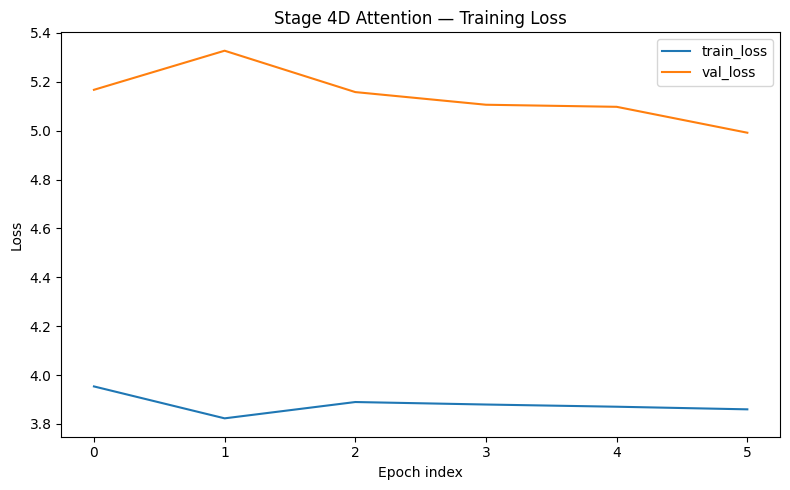

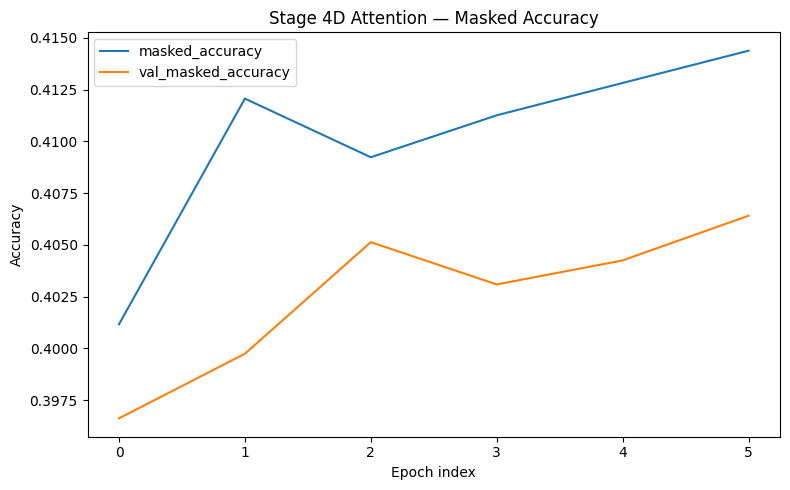

Saved training curves/history.


In [14]:
# CELL B — Save training history + curves
assert "history_finetune" in globals(), "Run Phase 2 fit cell first (history_finetune missing)."

hist_ft = pd.DataFrame(history_finetune.history)
hist_ft["phase"] = "finetune"

if "history_frozen" in globals():
    hist_fr = pd.DataFrame(history_frozen.history)
    hist_fr["phase"] = "frozen"
    hist_all = pd.concat([hist_fr, hist_ft], ignore_index=True)
else:
    hist_all = hist_ft.copy()

hist_all.to_csv(STAGE4D_ART / "training_history_combined.csv", index=False)
hist_ft.to_csv(STAGE4D_ART / "training_history_finetune.csv", index=False)

# Loss curve
plt.figure(figsize=(8, 5))
if "loss" in hist_all.columns:
    plt.plot(hist_all["loss"].values, label="train_loss")
if "val_loss" in hist_all.columns:
    plt.plot(hist_all["val_loss"].values, label="val_loss")
plt.title("Stage 4D Attention — Training Loss")
plt.xlabel("Epoch index")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(STAGE4D_ART / "training_curve_loss.png", dpi=180)
plt.show()

# Accuracy curve (if present)
acc_key = "masked_accuracy" if "masked_accuracy" in hist_all.columns else None
val_acc_key = "val_masked_accuracy" if "val_masked_accuracy" in hist_all.columns else None

if acc_key is not None or val_acc_key is not None:
    plt.figure(figsize=(8, 5))
    if acc_key is not None:
        plt.plot(hist_all[acc_key].values, label=acc_key)
    if val_acc_key is not None:
        plt.plot(hist_all[val_acc_key].values, label=val_acc_key)
    plt.title("Stage 4D Attention — Masked Accuracy")
    plt.xlabel("Epoch index")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(STAGE4D_ART / "training_curve_masked_accuracy.png", dpi=180)
    plt.show()

print("Saved training curves/history.")


In [15]:
# CELL C — Inference helpers + image path resolution
def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    return " ".join(s.split())

IMG_SIZE_LOCAL = int(globals().get("IMG_SIZE", model.inputs[0].shape[1]))

if "load_image_for_infer" not in globals():
    from tensorflow.keras.utils import load_img, img_to_array

    def load_image_for_infer(image_path: str):
        img = load_img(image_path, target_size=(IMG_SIZE_LOCAL, IMG_SIZE_LOCAL))
        arr = img_to_array(img).astype("float32")
        arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
        return np.expand_dims(arr, axis=0)

def decode_greedy_clean(model_obj, image_path: str, max_steps=None):
    if max_steps is None:
        max_steps = int(SEQ_LEN)

    image = load_image_for_infer(image_path)
    tokens = [int(start_id)]

    for _ in range(max_steps):
        dec_in = np.zeros((1, int(SEQ_LEN)), dtype=np.int32)
        use = tokens[:int(SEQ_LEN)]
        dec_in[0, :len(use)] = use

        pred = model_obj({"image_input": image, "text_input": dec_in}, training=False).numpy()[0]
        pos = min(len(use) - 1, int(SEQ_LEN) - 1)
        nxt = int(np.argmax(pred[pos]))

        if nxt == int(end_id) or nxt == 0:
            break
        tokens.append(nxt)

    words = []
    for tid in tokens[1:]:
        w = index_word.get(int(tid), "<unk>")
        if w not in ("<pad>", "<start>", "<end>", "<unk>"):
            words.append(w)

    return " ".join(words).strip() if words else "a person in a scene"

# Build image_paths dict robustly
if "image_paths" in globals() and isinstance(image_paths, dict) and len(image_paths) > 0:
    img_paths = {str(k): str(v) for k, v in image_paths.items()}
elif "image_path_by_name" in globals():
    img_paths = {str(k): str(v) for k, v in image_path_by_name.items()}
elif "df" in globals():
    tmp = df.copy()
    if "image_path_resolved" in tmp.columns:
        col = "image_path_resolved"
    elif "image_path" in tmp.columns:
        col = "image_path"
    else:
        raise RuntimeError("No image_path/image_path_resolved column found in df.")
    img_paths = (
        tmp.drop_duplicates("image_name")
           .assign(image_name=lambda x: x["image_name"].astype(str))
           .set_index("image_name")[col]
           .astype(str)
           .to_dict()
    )
else:
    raise RuntimeError("No source found for image paths (image_paths/image_path_by_name/df).")

EVAL_NAMES = sorted(pd.Series(test_names).astype(str).unique().tolist())
print("Resolved image_paths:", len(img_paths), "| test images:", len(EVAL_NAMES))


Resolved image_paths: 123287 | test images: 2500


In [16]:
# CELL D — Full test evaluation + save metrics/artifacts
sf = SmoothingFunction().method1

bleu1_scores, bleu2_scores, bleu3_scores, bleu4_scores = [], [], [], []
sample_rows = []

for n in tqdm(EVAL_NAMES, desc="Stage4D full BLEU eval"):
    if n not in img_paths:
        continue

    pred = normalize_text(decode_greedy_clean(model, img_paths[n]))
    refs_raw = references_by_image.get(n, [])
    refs = [normalize_text(r).split() for r in refs_raw if isinstance(r, str) and normalize_text(r)]

    if not refs:
        continue

    pt = pred.split()
    b1 = sentence_bleu(refs, pt, weights=(1, 0, 0, 0), smoothing_function=sf)
    b2 = sentence_bleu(refs, pt, weights=(0.5, 0.5, 0, 0), smoothing_function=sf)
    b3 = sentence_bleu(refs, pt, weights=(1/3, 1/3, 1/3, 0), smoothing_function=sf)
    b4 = sentence_bleu(refs, pt, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sf)

    bleu1_scores.append(b1)
    bleu2_scores.append(b2)
    bleu3_scores.append(b3)
    bleu4_scores.append(b4)

    if len(sample_rows) < 20:
        sample_rows.append({
            "image_name": n,
            "generated_caption": pred,
            "reference_caption_1": refs_raw[0] if len(refs_raw) else "",
            "bleu1": float(b1),
            "bleu4": float(b4),
        })

metrics = {
    "val_loss_best_finetune": float(np.min(history_finetune.history["val_loss"])) if "val_loss" in history_finetune.history else np.nan,
    "val_masked_accuracy_best_finetune": float(np.max(history_finetune.history["val_masked_accuracy"])) if "val_masked_accuracy" in history_finetune.history else np.nan,
    "test_bleu1": float(np.mean(bleu1_scores)) if bleu1_scores else 0.0,
    "test_bleu2": float(np.mean(bleu2_scores)) if bleu2_scores else 0.0,
    "test_bleu3": float(np.mean(bleu3_scores)) if bleu3_scores else 0.0,
    "test_bleu4": float(np.mean(bleu4_scores)) if bleu4_scores else 0.0,
    "eval_images_count": int(len(bleu1_scores)),
    "vocab_size": int(globals().get("VOCAB_SIZE", len(index_word) + 1)),
    "max_len": int(globals().get("MAX_LEN", int(SEQ_LEN) + 1)),
    "img_size": int(IMG_SIZE_LOCAL),
}

(STAGE4D_ART / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
pd.DataFrame(sample_rows).to_csv(STAGE4D_ART / "sample_caption_predictions.csv", index=False)

metrics_table = pd.DataFrame([
    {"metric": "val_loss_best_finetune", "value": metrics["val_loss_best_finetune"]},
    {"metric": "val_masked_accuracy_best_finetune", "value": metrics["val_masked_accuracy_best_finetune"]},
    {"metric": "test_bleu1", "value": metrics["test_bleu1"]},
    {"metric": "test_bleu2", "value": metrics["test_bleu2"]},
    {"metric": "test_bleu3", "value": metrics["test_bleu3"]},
    {"metric": "test_bleu4", "value": metrics["test_bleu4"]},
    {"metric": "eval_images_count", "value": metrics["eval_images_count"]},
])
metrics_table.to_csv(STAGE4D_ART / "metrics_table.csv", index=False)

# Save final model + tokenizer (if available)
model.save(STAGE4D_MODEL / "stage4d_attention_final.keras")
if "tokenizer" in globals():
    (STAGE4D_ART / "tokenizer.json").write_text(tokenizer.to_json(), encoding="utf-8")

print(json.dumps(metrics, indent=2))
print("Saved metrics/model/sample outputs.")


Stage4D full BLEU eval:   0%|          | 0/2500 [00:00<?, ?it/s]

{
  "val_loss_best_finetune": 4.991735458374023,
  "val_masked_accuracy_best_finetune": 0.40640610456466675,
  "test_bleu1": 0.0005241379310344826,
  "test_bleu2": 0.0001686807694150206,
  "test_bleu3": 0.0001170047941324921,
  "test_bleu4": 9.837172852534264e-05,
  "eval_images_count": 2500,
  "vocab_size": 30000,
  "max_len": 30,
  "img_size": 224
}
Saved metrics/model/sample outputs.


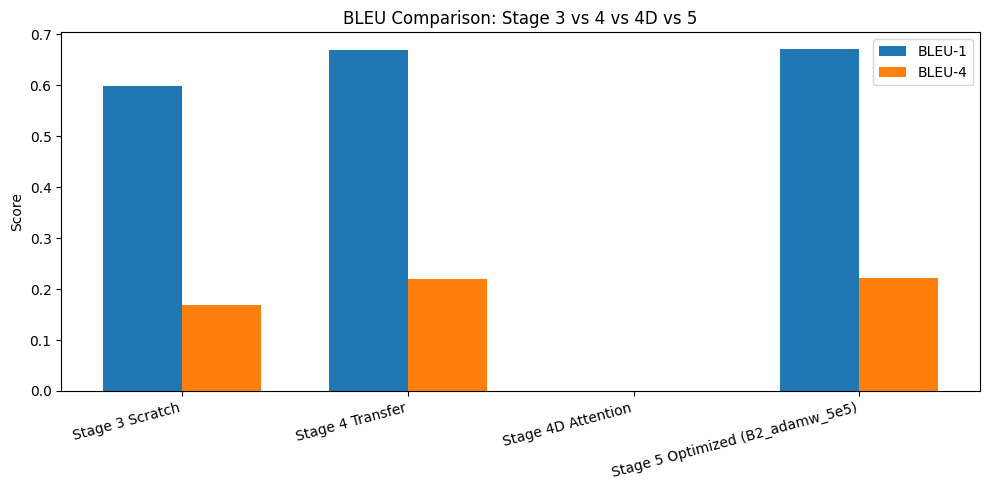

,stage,bleu1,bleu4
0,Stage 3 Scratch,0.598141,0.168521
1,Stage 4 Transfer,0.669339,0.219309
2,Stage 4D Attention,0.000524,0.000098
3,Stage 5 Optimized (B2_adamw_5e5),0.670514,0.222210


Saved comparison CSV + chart.


In [17]:
# CELL E — Comparison vs Stage 3/4/5 + chart
rows = []

m3_path = PROJECT_ROOT / "artifacts" / "stage3" / "metrics.json"
m4_path = PROJECT_ROOT / "artifacts" / "stage4" / "metrics.json"
m4d_path = STAGE4D_ART / "metrics.json"
m5_path = PROJECT_ROOT / "artifacts" / "stage5" / "stage4b_results_final.csv"

if m3_path.exists():
    m3 = json.loads(m3_path.read_text(encoding="utf-8"))
    rows.append({"stage": "Stage 3 Scratch", "bleu1": m3.get("test_bleu1", np.nan), "bleu4": m3.get("test_bleu4", np.nan)})

if m4_path.exists():
    m4 = json.loads(m4_path.read_text(encoding="utf-8"))
    rows.append({"stage": "Stage 4 Transfer", "bleu1": m4.get("test_bleu1", np.nan), "bleu4": m4.get("test_bleu4", np.nan)})

m4d = json.loads(m4d_path.read_text(encoding="utf-8"))
rows.append({"stage": "Stage 4D Attention", "bleu1": m4d.get("test_bleu1", np.nan), "bleu4": m4d.get("test_bleu4", np.nan)})

if m5_path.exists():
    d5 = pd.read_csv(m5_path)
    if "bleu4_full" in d5.columns and d5["bleu4_full"].notna().any():
        best5 = d5[d5["bleu4_full"].notna()].sort_values("bleu4_full", ascending=False).iloc[0]
        rows.append({"stage": f"Stage 5 Optimized ({best5['run_id']})", "bleu1": best5.get("bleu1_full", np.nan), "bleu4": best5.get("bleu4_full", np.nan)})
    else:
        best5 = d5.sort_values("bleu4_fast", ascending=False).iloc[0]
        rows.append({"stage": f"Stage 5 Optimized FAST ({best5['run_id']})", "bleu1": best5.get("bleu1_fast", np.nan), "bleu4": best5.get("bleu4_fast", np.nan)})

cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(STAGE4D_ART / "stage3_stage4_stage4d_stage5_comparison.csv", index=False)

plt.figure(figsize=(10, 5))
x = np.arange(len(cmp_df))
w = 0.35
plt.bar(x - w/2, cmp_df["bleu1"], width=w, label="BLEU-1")
plt.bar(x + w/2, cmp_df["bleu4"], width=w, label="BLEU-4")
plt.xticks(x, cmp_df["stage"], rotation=15, ha="right")
plt.ylabel("Score")
plt.title("BLEU Comparison: Stage 3 vs 4 vs 4D vs 5")
plt.legend()
plt.tight_layout()
plt.savefig(STAGE4D_ART / "chart_bleu_stage_comparison.png", dpi=180)
plt.show()

display(cmp_df)
print("Saved comparison CSV + chart.")


In [20]:
# CELL F — Gate (Stage 4D PASS)
required = [
    STAGE4D_ART / "metrics.json",
    STAGE4D_ART / "metrics_table.csv",
    STAGE4D_ART / "sample_caption_predictions.csv",
    STAGE4D_ART / "training_history_combined.csv",
    STAGE4D_ART / "training_curve_loss.png",
    STAGE4D_ART / "chart_bleu_stage_comparison.png",
    STAGE4D_ART / "stage3_stage4_stage4d_stage5_comparison.csv",
    STAGE4D_MODEL / "stage4d_attention_final.keras",
]

for p in required:
    assert p.exists(), f"Missing: {p}"

m = json.loads((STAGE4D_ART / "metrics.json").read_text(encoding="utf-8"))
assert not np.isnan(m["test_bleu1"]) and not np.isnan(m["test_bleu4"]), "BLEU contains NaN"

print("STAGE 4D ATTENTION PASS ")
print("BLEU-1:", round(m["test_bleu1"], 4), "| BLEU-4:", round(m["test_bleu4"], 4))


STAGE 4D ATTENTION PASS 
BLEU-1: 0.0005 | BLEU-4: 0.0001
